This notebook generates different types of labels depending on the hypothesis behind the labeling

In [1]:
import pandas as pd
import numpy as np
from pyprojroot import here
import matplotlib.pyplot as plt

processed_data = here('data/processed_data')

In [2]:
vars2keep = [
    'supplier_name_clean',
    'contract_year',
    'RFC'
]

In [3]:
#read feather
contracts = pd.read_feather(processed_data / 'mxc11to22_base.feather', columns=vars2keep)
contracts.shape

(2308908, 3)

In [4]:
contracts['prov_id'] = contracts.index

# Create sanctions dataset

### efos

In [5]:
#efos
efos = pd.read_csv(processed_data / 'efos_jan24.csv')

In [6]:
efos

,RFC,supplier_name,supplier_name_clean,supplier_situation,presumed_publication_date,sanction_year
0,AAA080808HL8,"ASESORES EN AVALÚOS Y ACTIVOS, S.A. DE C.V.",asesoresenavaluosyactivossadecv,Sentencia Favorable,2018-06-01,2018
1,AAA120730823,"ASESORES Y ADMINISTRADORES AGRICOLAS, S. DE R....",asesoresyadministradoresagricolassderldecv,Definitivo,2017-01-01,2017
2,AAA121206EV5,"AMÉRICA ADMINISTRATIVA ARROLLO, S.A. DE CV.",americaadministrativaarrollosadecv,Definitivo,2019-04-01,2019
3,AAA140116926,"AVALOS & ASOCIADOS CONSULTORIA INTEGRAL, S.C.",avalosasociadosconsultoriaintegralsc,Definitivo,2020-11-03,2020
4,AAA1502061S0,ACUESY ASESORÍA ACUICOLA ESPECIALIZADA DE YUCA...,acuesyasesoriaacuicolaespecializadadeyucatansa...,Sentencia Favorable,2017-09-18,2017
...,...,...,...,...,...,...
12465,ZTP101230N53,"ZARATE TOLEDO Y PACHECO GRUPO CONSULTOR, S.A. ...",zaratetoledoypachecogrupoconsultorsadecv,Definitivo,2016-10-01,2016
12466,ZUCV601108NYA,ZÚÑIGA CASTILLO VÍCTOR,zunigacastillovictor,Definitivo,2017-06-01,2017
12467,ZUL131022LD6,"ZULPER, S.A. DE C.V.",zulpersadecv,Definitivo,2018-05-01,2018
12468,ZULM591126520,ZUÑIGA LEMUS MANUEL,zunigalemusmanuel,Definitivo,2018-08-02,2018


In [7]:
#efos
efos = pd.read_csv(processed_data / 'efos_jan24.csv')
efos = efos[efos['supplier_situation'] != 'Sentencia Favorable'].reset_index(drop=True)
efos = efos[['sanction_year', 'supplier_name_clean', 'RFC']]
efos_rfc = efos.set_index('supplier_name_clean')['RFC'].to_dict()
efos = efos[['sanction_year', 'supplier_name_clean']].drop_duplicates()

In [8]:
efos.shape

(10988, 2)

### PCS

In [9]:
#read csv file
pcs = pd.read_csv(processed_data / 'pcs_merged.csv')

In [10]:
pcs

,file_number,supplier_name,supplier_name_clean,source,sanction_time,resolution
0,0043/2021,128 ARQUITECTURA Y DISEÑO URBANO S.C.,128arquitecturaydisenourbanosc,da_april2023,1 AÑO 6 MESES,SANCIONATORIA CON MULTA E INHABILITACIÓN
1,0041/2013,3R INNOVACIÓN Y DISEÑO S.A. DE C.V.,3rinnovacionydisenosadecv,da_april2023,NaN,SANCIONATORIA CON MULTA
2,0002/2016,A AND P INTERNATIONAL,aandpinternational,da_april2023,4 AÑOS,SANCIONATORIA CON MULTA E INHABILITACIÓN
3,0121/2006,A Y M CONSTRUCTORA S.A. DE C.V.,aymconstructorasadecv,da_april2023,3 MESES,SANCIONATORIA CON MULTA E INHABILITACIÓN
4,0001/2013,A Y V INDUSTRIAL Y COMERCIAL S.A. DE C.V.,ayvindustrialycomercialsadecv,da_april2023,3 MESES,SANCIONATORIA CON MULTA E INHABILITACIÓN
...,...,...,...,...,...,...
2582,0407/2008,TRANSPORTES COMERCIALES Y PAQUETERIA S.A. DE ...,transportescomercialesypaqueteriasadecv,f_march2021,NaN,SANCIONATORIA CON MULTA
2583,0027/2014,UNIFORMES Y ACCESORIOS DE LA PAZ S.A. DE C.V.,uniformesyaccesoriosdelapazsadecv,f_march2021,NaN,SANCIONATORIA CON MULTA
2584,0002/2019,VALUACIÓN OPERATIVA Y REFERENCIAS DE MERCADO S...,valuacionoperativayreferenciasdemercadosadecv,f_march2021,NaN,SANCIONATORIA CON MULTA
2585,0031/2019,VIDRIERÍA Y REACTIVOS S.A. DE C.V.,vidrieriayreactivossadecv,f_march2021,NaN,SANCIONATORIA CON MULTA


In [11]:
#Assumption: sanction is closer to the file number
pcs['sanction_year'] = pcs['file_number'].str.split('/').str[1]
pcs['sanction_year'] = pcs['sanction_year'].astype(int) 
############################################################################# sanction time
pcs['sanction_time'] = pcs['sanction_time'].fillna('0')
pcs['sanction_time'] = pcs['sanction_time'].str.lower()
pcs['sanction_time'] = pcs['sanction_time'].str.replace('un', '1', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('tres', '3', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('null130', '0', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('null146', '0', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('null26', '0', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace(',', '', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('años', 'year', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('año', 'year', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('meses', 'month', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace('mes', 'month', regex=False)
pcs['sanction_time'] = pcs['sanction_time'].str.replace(' ', '', regex=False)
pcs['years'] = pcs['sanction_time'].str.extract(r'(\d+)year')
pcs['years'] = pcs['years'].fillna('0')
pcs['years2months'] = pcs['years'].astype(int) * 12
pcs['months'] = pcs['sanction_time'].str.extract(r'(\d+)month')
pcs['months'] = pcs['months'].fillna('0')
pcs['months'] = pcs['months'].astype(int)
pcs['sanction_months'] = pcs['years2months'] + pcs['months']


In [12]:
pcs = pcs[['sanction_year', 'supplier_name_clean', 'sanction_months']]

In [13]:
#remove duplicates
print(pcs.shape)
pcs = pcs.drop_duplicates(subset=['supplier_name_clean', 'sanction_year', 'sanction_months'], keep='first')
print(pcs.shape)

(2587, 3)
(2373, 3)


In [14]:
pcs = pcs.groupby(['supplier_name_clean', 'sanction_year'])['sanction_months'].idxmax().reset_index()
print(pcs.shape)

(2306, 3)


In [15]:
pcs['sanction_months'].min()

0

In [16]:
set(pcs['supplier_name_clean']).intersection(set(efos['supplier_name_clean']))

{'cenlav2005sadecv',
 'consorciocorporativodeconstruccionenmexicosadecv',
 'consorciomlsadecv',
 'corporaciondeingenieroscivilesyarquitectosmexicanossadecv',
 'drmacerosinternacionalsadecv',
 'grupoabcgraficssadecv',
 'habitatterrasadecv',
 'incodesinmobiliariaconstructoresydesarrolladoressadecv',
 'interaccionbiomedicasadecv',
 'quadrumlimpiezayconstruccionsadecv'}

### sanctions = pcs + efos

In [17]:
sanctions = pd.concat([pcs, efos], axis=0)
sanctions['sanction_year'] = sanctions['sanction_year'].astype(int)

In [18]:
#remove duplicates
print(sanctions.shape)
sanctions = sanctions.drop_duplicates(subset=['supplier_name_clean', 'sanction_year', 'sanction_months'], keep='first')
print(sanctions.shape)

(13294, 3)
(13294, 3)


In [19]:
#be sure that the sanctioned companies have at least one contract in the contracts dataset
suppliers_in_c = contracts['supplier_name_clean'].unique()
print(sanctions.shape)
sanctions = sanctions[sanctions['supplier_name_clean'].isin(suppliers_in_c)].reset_index(drop=True)
print(sanctions.shape)

(13294, 3)
(1847, 3)


In [20]:
#keep only sanctions after 2010
sanctions = sanctions[sanctions['sanction_year']> 2010].reset_index(drop=True)
sanctions['sanction_year'].unique()

array([2013, 2019, 2015, 2021, 2022, 2014, 2020, 2017, 2012, 2016, 2011,
       2023, 2018])

In [21]:
sanctioned_suppliers_names = sanctions['supplier_name_clean'].unique()

# Distance between sanction year and contract year

Creation of sanctions_distance df

In [22]:
contracts_years = contracts.copy()
contracts_years = contracts_years[['supplier_name_clean', 'contract_year', 'prov_id']]
#contracts_years = contracts_years.drop_duplicates(subset=['supplier_name_clean', 'contract_year'])

In [23]:
sanctions_distance = sanctions.copy()
sanctions_distance = sanctions_distance.merge(contracts_years[['supplier_name_clean', 'contract_year', 'prov_id']], on='supplier_name_clean', how='left')

In [24]:
#there are no companies with only fee penalty associated with a contract
sanctions_distance['sanction_months'].min()

1.0

In [25]:
# contract is negative if contract year is before sanction
#contract is positive if contract year is after sanction
sanctions_distance['difference'] = sanctions_distance['contract_year'] - sanctions_distance['sanction_year']
sanctions_distance

,supplier_name_clean,sanction_year,sanction_months,contract_year,prov_id,difference
0,3rinnovacionydisenosadecv,2013,1.0,2012,19318,-1
1,3rinnovacionydisenosadecv,2013,1.0,2013,34461,0
2,3rinnovacionydisenosadecv,2013,1.0,2013,410728,0
3,3rinnovacionydisenosadecv,2013,1.0,2015,757138,2
4,3rinnovacionydisenosadecv,2013,1.0,2015,757139,2
...,...,...,...,...,...,...
93794,zebimesadecv,2017,NaN,2013,439565,-4
93795,zebimesadecv,2017,NaN,2016,956488,-1
93796,zazilhualsadecv,2017,NaN,2014,511977,-3
93797,zazilhualsadecv,2017,NaN,2015,762778,-2


In [26]:
#companies with sanctions whose totallity of contracts are only after the sanction don't make sense
idx = sanctions_distance.groupby('supplier_name_clean')['difference'].idxmin()
inconsistent_suppliers =  sanctions_distance.loc[idx].reset_index()
inconsistent_suppliers = inconsistent_suppliers[inconsistent_suppliers['difference'] > 0]['supplier_name_clean'].unique()
print(inconsistent_suppliers.shape)
inconsistent_suppliers

(24,)


array(['apltechnologysadecv', 'asesoriaavanzadaenbasculasaabsadecv',
       'basfingenieriaespecializadasadecv',
       'carlosalbertosoteloregilhernandez',
       'centroparaeldesarrollointegralylacompetitividaddelturismoenareasruralessc',
       'comercializadoramorgonsadecv', 'comercializadorariuasderldecv',
       'corporateenergymastersadecv', 'covisacomercializadorasadecv',
       'davidcarrizalmartinez', 'distribuidoramedicicursadecv',
       'distribuidoraycomercializadoraportluevsadecv',
       'josealfredohoyoshernandez', 'medicoresadecv',
       'muropavimentosyconstruccionessadecv',
       'omnibusytransportesterrestresejecutivossadecv',
       'prestadoradeserviciospacificonortesadecv',
       'radiadorescontinentalsadecv', 'sellandservicesadecv',
       'solucionesintegralescorporativaspasadecv',
       'solvalledoradosapidecv', 'talleresyaltamecanicasadecv',
       'terraceriasymineralessadecv', 'zzoconstruccionessadecv'],
      dtype=object)

In [27]:
print(sanctions_distance.shape)
sanctions_distance = sanctions_distance[~sanctions_distance['supplier_name_clean'].isin(inconsistent_suppliers)].reset_index(drop = True)
print(sanctions_distance.shape)


(93799, 6)
(93648, 6)


# One and repeat offenders

In [28]:
#I also need a reliable sanction dataset from where i can separate repeated offenders from one time offenders
sanctions_count = sanctions_distance[['sanction_year', 'supplier_name_clean']].drop_duplicates()
sanctions_count = sanctions_count.copy()['supplier_name_clean'].value_counts().reset_index(name = 'count')
sanctions_count.rename(columns = {'index' : 'supplier_name_clean'}, inplace=True)
#One time offenders are those that in my dataset of sanctionsappear only once, independently of the number of contracts
onet_offenders = sanctions_count[sanctions_count['count'] == 1]['supplier_name_clean'].unique()
sanctions_distance_onet = sanctions_distance[sanctions_distance['supplier_name_clean'].isin(onet_offenders)].reset_index(drop=True)
#repeated ofenders are those that appear in my sanctions datased, independenty of the number of contracts
rep_offenders = sanctions_count[sanctions_count['count'] > 1]['supplier_name_clean'].unique()
sanctions_distance_rep = sanctions_distance[sanctions_distance['supplier_name_clean'].isin(rep_offenders)].reset_index(drop=True)
len(onet_offenders), len(rep_offenders), len(onet_offenders) + len(rep_offenders)

(1584, 82, 1666)

In [29]:
sanctions_distance_rep = sanctions_distance_rep.groupby('prov_id').max()

In [30]:
sanctions_distance_rep = sanctions_distance_rep.drop(columns=['sanction_year', 'contract_year', 'difference'])

# save sanction distance

In [31]:
sanctions_distance2save = sanctions_distance.copy()
sanctions_distance2save['onetimeoffender'] = np.where(sanctions_distance2save['supplier_name_clean'].isin(onet_offenders), 1, 0)
sanctions_distance2save['repeatedoffender'] = np.where(sanctions_distance2save['supplier_name_clean'].isin(rep_offenders), 1, 0)
sanctions_distance2save.to_feather(processed_data / 'sanctions_distance.feather')

# Difference between closest and inclusive strategy

There are two labeling strategies in hypothesis A: closest contracts strategy and inclusive strategy. Refinements of the labeling strategies are made with k, being k = {1,2,3} the distance d in years (contract year - sanction year).

a) Closest contracts strategy. We will label as positive to the contracts of supplier X that are immediatly before the sanction year, regardless of the distance to the sanction. The advantage of this strategy is that all sanctioned suppliers would have at least one positive example. The disadvantage is that, without limits, we are allowing to label contracts that potentially could have a distance of 9 years to the sanction. Therefore we will assign a maximum k to the labeling process, where a contract would only being labeled if the distance (d < 0) is equal or lower than k. Each increase in k adds new companies to the dataset. Mantra: one contract per sanction => more than one contract per supplier if is repeat offender.

b) Inclusive strategy. We will label as positive to all the contracts of sanctioned suppliers before their corresponding sanction year (d < 0). The advantage of this approach is that we get a great amount of labels, however, we lose precision since we are including not only contracts with very far distance, but also disproportionally labels from suppliers with high number of contracts. We assign a maximum range of k to the labeling process, so that a contract would only being labeled if the distance (d < 0) is equal or lower than k. Each increase in k adds more contracts but not necessary much more companies.

In [32]:
#Closest POSITIVE DISTANCES
closestS_pos = sanctions_distance.copy()
closestS_pos = closestS_pos[closestS_pos['difference'] >= 0].reset_index(drop=True)
#POSITIVE DISTANCES
#get the index of the minimum first occurrence 
idx = closestS_pos.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmin()
dfloc = closestS_pos.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 0
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
closestS_pos = closestS_pos.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
closestS_pos = closestS_pos[closestS_pos['match'] == 0].reset_index(drop=True)

#Closest NEGATIVE DISTANCES
closestS_neg = sanctions_distance.copy()
closestS_neg = closestS_neg[closestS_neg['difference'] < 0].reset_index(drop=True)
#get the index of the maximum first occurrence 
idx = closestS_neg.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmax()
dfloc = closestS_neg.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 1
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
closestS_neg = closestS_neg.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
closestS_neg = closestS_neg[closestS_neg['match'] == 1].reset_index(drop=True)

#all together
closestS = pd.concat([closestS_pos, closestS_neg]).reset_index(drop=True)


In [33]:
closestS['supplier_name_clean'].nunique()

1666

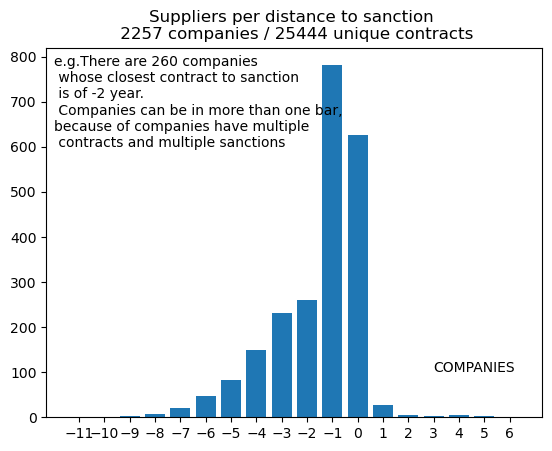

In [34]:
#Closest Suppliers
df2plot = closestS.copy()
#Plot preparation
unique_contracts = df2plot['prov_id'].nunique()
df2plot = df2plot.groupby('difference')['supplier_name_clean'].nunique().reset_index()
nsuppliers = df2plot['supplier_name_clean'].sum()
#df2plot['supplier_name_clean_norm'] = df2plot['supplier_name_clean'] / nsuppliers

#Plot
plt.bar(x = df2plot['difference'], height= df2plot['supplier_name_clean'])
plt.xticks(list(range(np.min(df2plot['difference']), np.max(df2plot['difference']) + 1)))
plt.title(f'''Suppliers per distance to sanction \n {nsuppliers} companies / {unique_contracts} unique contracts''')
plt.annotate('e.g.There are 260 companies \n whose closest contract to sanction \n is of -2 year. \n Companies can be in more than one bar, \nbecause of companies have multiple \n contracts and multiple sanctions', xy = (-12, 600))
plt.annotate('COMPANIES', xy = (3, 100))
plt.show()

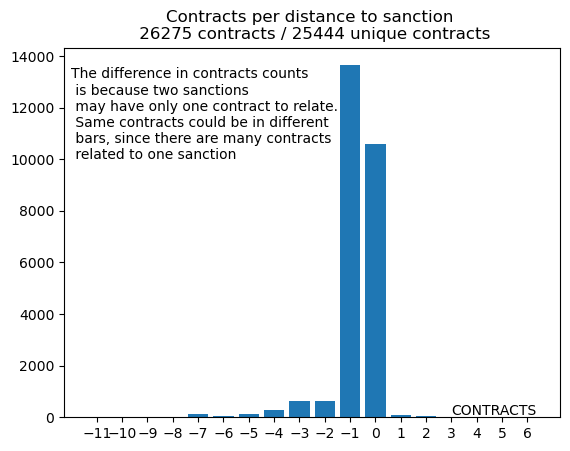

In [35]:
#Closest Contracts
df2plot = closestS.copy()
#Plot preparation
unique_contracts = df2plot['prov_id'].nunique()
df2plot = df2plot.groupby('difference')['prov_id'].nunique().reset_index()
ncontracts = df2plot['prov_id'].sum()
#df2plot['prov_id_norm'] = df2plot['prov_id'] / ncontracts

#Plot
plt.bar(x = df2plot['difference'], height= df2plot['prov_id'])
plt.xticks(list(range(np.min(df2plot['difference']), np.max(df2plot['difference']) + 1)))
plt.title(f'''Contracts per distance to sanction \n {ncontracts} contracts / {unique_contracts} unique contracts''')
plt.annotate('The difference in contracts counts \n is because two sanctions \n may have only one contract to relate. \n Same contracts could be in different \n bars, since there are many contracts \n related to one sanction', xy = (-12, 10000))
plt.annotate('CONTRACTS', xy = (3, 100))
plt.show()

(17963, 8)


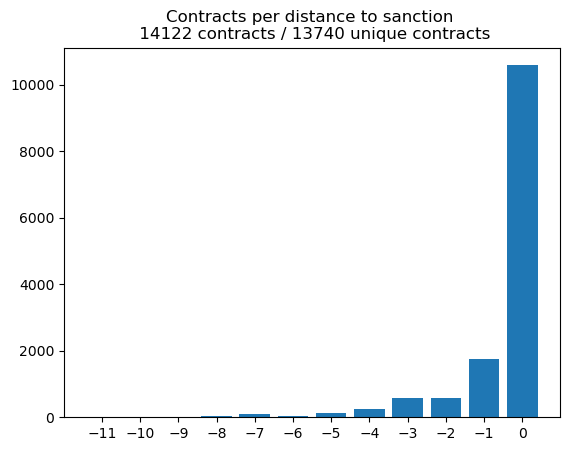

In [36]:
#INCLUDING 0 AS CORRUPT
closestS_pos = sanctions_distance.copy()
closestS_pos = closestS_pos[closestS_pos['difference'] > 0].reset_index(drop=True)
#POSITIVE DISTANCES
#get the index of the minimum first occurrence 
idx = closestS_pos.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmin()
dfloc = closestS_pos.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 0
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
closestS_pos = closestS_pos.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
closestS_pos = closestS_pos[closestS_pos['match'] == 0].reset_index(drop=True)

#Closest NEGATIVE DISTANCES
closestS_neg = sanctions_distance.copy()
closestS_neg = closestS_neg[closestS_neg['difference'] <= 0].reset_index(drop=True)
#get the index of the maximum first occurrence 
idx = closestS_neg.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmax()
dfloc = closestS_neg.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 1
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
closestS_neg = closestS_neg.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
closestS_neg = closestS_neg[closestS_neg['match'] == 1].reset_index(drop=True)

#all together
closestS = pd.concat([closestS_pos, closestS_neg]).reset_index(drop=True)

print(closestS.shape)


#Closest Contracts
df2plot = closestS.copy()
df2plot = df2plot[df2plot['difference']<=0].reset_index()
#Plot preparation
unique_contracts = df2plot['prov_id'].nunique()
df2plot = df2plot.groupby('difference')['prov_id'].nunique().reset_index()
ncontracts = df2plot['prov_id'].sum()
#df2plot['prov_id_norm'] = df2plot['prov_id'] / ncontracts

#Plot
plt.bar(x = df2plot['difference'], height= df2plot['prov_id'])
plt.xticks(list(range(np.min(df2plot['difference']), np.max(df2plot['difference']) + 1)))
plt.title(f'''Contracts per distance to sanction \n {ncontracts} contracts / {unique_contracts} unique contracts''')
#plt.annotate('The difference in contracts counts \n is because two sanctions \n may have only one contract to relate. \n Same contracts could be in different \n bars, since there are many contracts \n related to one sanction', xy = (-12, 10000))
#plt.annotate('CONTRACTS', xy = (3, 100))
plt.show()

(19390, 8)


Text(0.5, 1.0, 'Contracts per distance to sanction \n 15549 contracts / 15451 unique contracts')

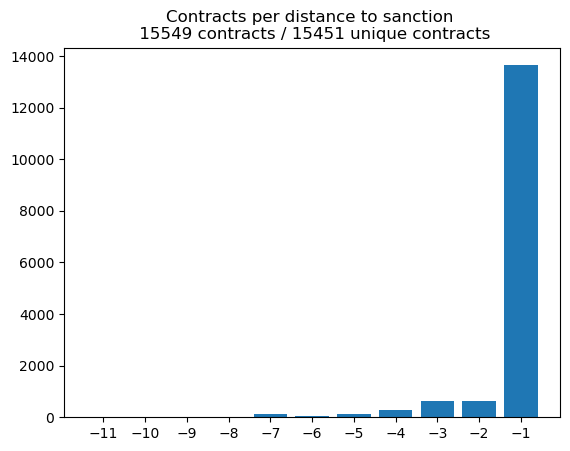

In [37]:
#0 IS AMBIGUOS SO WE DELETE IT
closestS_pos = sanctions_distance.copy()
closestS_pos = closestS_pos[closestS_pos['difference'] > 0].reset_index(drop=True)
#POSITIVE DISTANCES
#get the index of the minimum first occurrence 
idx = closestS_pos.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmin()
dfloc = closestS_pos.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 0
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
closestS_pos = closestS_pos.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
closestS_pos = closestS_pos[closestS_pos['match'] == 0].reset_index(drop=True)

#Closest NEGATIVE DISTANCES
closestS_neg = sanctions_distance.copy()
closestS_neg = closestS_neg[closestS_neg['difference'] < 0].reset_index(drop=True)
#get the index of the maximum first occurrence 
idx = closestS_neg.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmax()
dfloc = closestS_neg.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 1
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
closestS_neg = closestS_neg.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
closestS_neg = closestS_neg[closestS_neg['match'] == 1].reset_index(drop=True)

#all together
closestS = pd.concat([closestS_pos, closestS_neg]).reset_index(drop=True)


print(closestS.shape)

#Closest Contracts
df2plot = closestS.copy()
df2plot = df2plot[df2plot['difference']< 0].reset_index()
#Plot preparation
unique_contracts = df2plot['prov_id'].nunique()
df2plot = df2plot.groupby('difference')['prov_id'].nunique().reset_index()
ncontracts = df2plot['prov_id'].sum()
#df2plot['prov_id_norm'] = df2plot['prov_id'] / ncontracts

#Plot
plt.bar(x = df2plot['difference'], height= df2plot['prov_id'])
plt.xticks(list(range(np.min(df2plot['difference']), np.max(df2plot['difference']) + 1)))
plt.title(f'''Contracts per distance to sanction \n {ncontracts} contracts / {unique_contracts} unique contracts''')
#plt.annotate('The difference in contracts counts \n is because two sanctions \n may have only one contract to relate. \n Same contracts could be in different \n bars, since there are many contracts \n related to one sanction', xy = (-12, 10000))
#plt.annotate('CONTRACTS', xy = (3, 100))

# Hypothesis A

Sanctions have unknown effect

- Before and after the sanction period the contracts are unlabeled
- All repeat offenders contracts are labeled positive




In [38]:
#Sanctions distance are contracts matched with a sanctioned company
hypothesisA = sanctions_distance.copy()
hypothesisA

,supplier_name_clean,sanction_year,sanction_months,contract_year,prov_id,difference
0,3rinnovacionydisenosadecv,2013,1.0,2012,19318,-1
1,3rinnovacionydisenosadecv,2013,1.0,2013,34461,0
2,3rinnovacionydisenosadecv,2013,1.0,2013,410728,0
3,3rinnovacionydisenosadecv,2013,1.0,2015,757138,2
4,3rinnovacionydisenosadecv,2013,1.0,2015,757139,2
...,...,...,...,...,...,...
93643,zebimesadecv,2017,NaN,2013,439565,-4
93644,zebimesadecv,2017,NaN,2016,956488,-1
93645,zazilhualsadecv,2017,NaN,2014,511977,-3
93646,zazilhualsadecv,2017,NaN,2015,762778,-2


In [39]:
#there are duplicate contracts given that the merge is by supplier_name_clean
#therefore each prov_id is tied to a contract year
#and each contract year is duplicated for each sanction year
#repeat offenders duplicate contracts
#sanction year | supplier | contract year | prov_id | difference
#   2019       |    s1    |  2014         |    1    |     -5
#   2019       |    s1    |  2014         |    2    |     -5
#   2019       |    s1    |  2014         |    3    |     -5      
#   2019       |    s1    |  2012         |    4    |     -7
#   2019       |    s1    |  2012         |    5    |     -7
#   2017       |    s1    |  2014         |    1    |     -3
#   2017       |    s1    |  2014         |    2    |     -3
#   2017       |    s1    |  2014         |    3    |     -3
#   2017       |    s1    |  2012         |    4    |     -5
#   2017       |    s1    |  2012         |    5    |     -5
hypothesisA['prov_id'].nunique()

81138

In [40]:
hypothesisA['supplier_name_clean'].nunique()

1666

### Hypothesis A - Closest

In [41]:
#HYPOTHESIS A_Closest POSITIVE DISTANCES
hypothesisA_C_pos = hypothesisA.copy()
hypothesisA_C_pos = hypothesisA_C_pos[hypothesisA_C_pos['difference'] >= 0].reset_index(drop=True)
#POSITIVE DISTANCES
hypothesisA_C_pos['match'] = 0 #zero means unlabeled

#HYPOTHESIS A_Closest NEGATIVE DISTANCES
hypothesisA_C_neg = hypothesisA.copy()
hypothesisA_C_neg = hypothesisA_C_neg[hypothesisA_C_neg['difference'] < 0].reset_index(drop=True)
#get the index of the maximum first occurrence 
idx = hypothesisA_C_neg.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmax()
dfloc = hypothesisA_C_neg.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 1 #one means positively labeled
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
hypothesisA_C_neg = hypothesisA_C_neg.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])

#all together
hypothesisA_C = pd.concat([hypothesisA_C_pos, hypothesisA_C_neg]).reset_index(drop=True)
hypothesisA_C.rename(columns={'match' : 'sanctionedA_C_all'}, inplace = True)
hypothesisA_C['rep_offender'] = np.where(hypothesisA_C['supplier_name_clean'].isin(rep_offenders), 1, 0)

#sanctionedB_C_all and repeated offenders
hypothesisA_C['sanctionedA_C_all'] = np.where(hypothesisA_C['supplier_name_clean'].isin(rep_offenders), 1, hypothesisA_C['sanctionedA_C_all'])


#A_C_max1
condition_A_C = [
    (hypothesisA_C['difference'] == -1) | (hypothesisA_C['rep_offender'] == 1), # 1 positive
    ]
choices_A_C = [1]
hypothesisA_C['sanctionedA_C_max1'] = np.select(condition_A_C, choices_A_C, default=0)
#A_C_max2
condition_A_C = [
    (hypothesisA_C['difference'].isin([-1, -2])) | (hypothesisA_C['rep_offender'] == 1), # 1 positive
    ]
choices_A_C = [1]
hypothesisA_C['sanctionedA_C_max2'] = np.select(condition_A_C, choices_A_C, default=0)
#A_C_max3
condition_A_C = [
    (hypothesisA_C['difference'].isin([-1, -2, -3])) | (hypothesisA_C['rep_offender'] == 1), # 1 positive
    ]
choices_A_C = [1]
hypothesisA_C['sanctionedA_C_max3'] = np.select(condition_A_C, choices_A_C, default=0)

hypothesisA_C['at_least_one'] = hypothesisA_C[['sanctionedA_C_all',
                               'sanctionedA_C_max1',
                               'sanctionedA_C_max2',
                               'sanctionedA_C_max3']].sum(axis=1)

hypothesisA_C = hypothesisA_C[hypothesisA_C['at_least_one'] > 0].reset_index(drop=True)

#repeat offendersprint(hypothesisA_C.shape)
hypothesisA_C = hypothesisA_C[['prov_id',
                               'sanction_year',
                               'sanctionedA_C_all',
                               'sanctionedA_C_max1',
                               'sanctionedA_C_max2',
                               'sanctionedA_C_max3']].groupby('prov_id').max().reset_index()



In [42]:
contracts.shape

(2308908, 4)

In [43]:
hypothesisA_C[['sanctionedA_C_all',
                'sanctionedA_C_max1',
                'sanctionedA_C_max2',
                'sanctionedA_C_max3']].sum() 

sanctionedA_C_all     16630
sanctionedA_C_max1    14992
sanctionedA_C_max2    15540
sanctionedA_C_max3    16092
dtype: int64

In [44]:
hypothesisA_C[['sanctionedA_C_all',
                'sanctionedA_C_max1',
                'sanctionedA_C_max2',
                'sanctionedA_C_max3']].sum() / contracts.shape[0]

sanctionedA_C_all     0.007203
sanctionedA_C_max1    0.006493
sanctionedA_C_max2    0.006730
sanctionedA_C_max3    0.006970
dtype: float64

In [45]:
hypothesisA_C['sanctionedA_C_all'].sum()


16630

## HYPOTHESIS A_Inclusive

In [46]:
#HYPOTHESIS A_Inclusive POSITIVE DISTANCES
hypothesisA_I_pos = hypothesisA.copy()
hypothesisA_I_pos = hypothesisA_I_pos[hypothesisA_I_pos['difference'] >= 0].reset_index(drop=True)
hypothesisA_I_pos['sanctionedA_I_all'] = 0

#HYPOTHESIS A_Closest NEGATIVE DISTANCES
hypothesisA_I_neg = hypothesisA.copy()
hypothesisA_I_neg = hypothesisA_I_neg[hypothesisA_I_neg['difference'] < 0].reset_index(drop=True)
hypothesisA_I_neg['sanctionedA_I_all'] = 1

#all together
hypothesisA_I = pd.concat([hypothesisA_I_pos, hypothesisA_I_neg]).reset_index(drop=True)
hypothesisA_I['rep_offender'] = np.where(hypothesisA_I['supplier_name_clean'].isin(rep_offenders), 1, 0)

#sanctionedA_I_all
hypothesisA_I['sanctionedA_I_all'] = np.where(hypothesisA_I['supplier_name_clean'].isin(rep_offenders), 1, hypothesisA_I['sanctionedA_I_all'])

#A_C_max1
condition_A_I = [
    (hypothesisA_I['difference'] == -1) | (hypothesisA_I['rep_offender'] == 1), # 1 positive
    ]
choices_A_I = [1]
hypothesisA_I['sanctionedA_I_max1'] = np.select(condition_A_I, choices_A_I, default=0)
#A_C_max2
condition_A_I = [
    (hypothesisA_I['difference'].isin([-1, -2])) | (hypothesisA_I['rep_offender'] == 1), # 1 positive
    ]
choices_A_I = [1]
hypothesisA_I['sanctionedA_I_max2'] = np.select(condition_A_I, choices_A_I, default=0)
#A_C_max3
condition_A_I = [
    (hypothesisA_I['difference'].isin([-1, -2, -3])) | (hypothesisA_I['rep_offender'] == 1), # 1 positive
    ]
choices_A_I = [1]
hypothesisA_I['sanctionedA_I_max3'] = np.select(condition_A_I, choices_A_I, default=0)

hypothesisA_I['at_least_one'] = hypothesisA_I[['sanctionedA_I_all',
                               'sanctionedA_I_max1',
                               'sanctionedA_I_max2',
                               'sanctionedA_I_max3']].sum(axis=1)

hypothesisA_I = hypothesisA_I[hypothesisA_I['at_least_one'] > 0].reset_index(drop=True)

#repeat offendersprint(hypothesisA_I.shape)
hypothesisA_I = hypothesisA_I[['prov_id',
                               'sanction_year',
                               'sanctionedA_I_all',
                               'sanctionedA_I_max1',
                               'sanctionedA_I_max2',
                               'sanctionedA_I_max3']].groupby('prov_id').max().reset_index()

In [47]:
hypothesisA_I[['sanctionedA_I_all',
                'sanctionedA_I_max1',
                'sanctionedA_I_max2',
                'sanctionedA_I_max3']].sum()

sanctionedA_I_all     63879
sanctionedA_I_max1    19943
sanctionedA_I_max2    32310
sanctionedA_I_max3    40863
dtype: int64

In [48]:
hypothesisA_I[['sanctionedA_I_all',
                'sanctionedA_I_max1',
                'sanctionedA_I_max2',
                'sanctionedA_I_max3']].sum() / contracts.shape[0]

sanctionedA_I_all     0.027666
sanctionedA_I_max1    0.008637
sanctionedA_I_max2    0.013994
sanctionedA_I_max3    0.017698
dtype: float64

# Hypothesis B

The sanction has no dissuasive effect on company behavior. Contracts before and after sanction are labeled as positive


In [49]:
hypothesisB = sanctions_distance.copy()
hypothesisB

,supplier_name_clean,sanction_year,sanction_months,contract_year,prov_id,difference
0,3rinnovacionydisenosadecv,2013,1.0,2012,19318,-1
1,3rinnovacionydisenosadecv,2013,1.0,2013,34461,0
2,3rinnovacionydisenosadecv,2013,1.0,2013,410728,0
3,3rinnovacionydisenosadecv,2013,1.0,2015,757138,2
4,3rinnovacionydisenosadecv,2013,1.0,2015,757139,2
...,...,...,...,...,...,...
93643,zebimesadecv,2017,NaN,2013,439565,-4
93644,zebimesadecv,2017,NaN,2016,956488,-1
93645,zazilhualsadecv,2017,NaN,2014,511977,-3
93646,zazilhualsadecv,2017,NaN,2015,762778,-2


## Hypothesis B Closest

In [50]:
#HYPOTHESIS C_Closest POSITIVE DISTANCES
hypothesisB_C_pos = hypothesisB.copy()
hypothesisB_C_pos = hypothesisB_C_pos[hypothesisB_C_pos['difference'] >= 0].reset_index(drop=True)
#POSITIVE DISTANCES
#get the index of the minimum first occurrence 
idx = hypothesisB_C_pos.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmin()
dfloc = hypothesisB_C_pos.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 1
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
hypothesisB_C_pos = hypothesisB_C_pos.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
hypothesisB_C_pos = hypothesisB_C_pos[hypothesisB_C_pos['match'] == 1].reset_index(drop=True)

#HYPOTHESIS B_Closest NEGATIVE DISTANCES
hypothesisB_C_neg = hypothesisB.copy()
hypothesisB_C_neg = hypothesisB_C_neg[hypothesisB_C_neg['difference'] < 0].reset_index(drop=True)
#get the index of the maximum first occurrence 
idx = hypothesisB_C_neg.groupby(['sanction_year', 'supplier_name_clean'])['difference'].idxmax()
dfloc = hypothesisB_C_neg.loc[idx].reset_index(drop=True).drop(columns='prov_id')
dfloc['match'] = 1
dfloc.drop(columns='contract_year', inplace=True)
#i have to merge it to get all the contracts with same sanction year, supplier, and difference
hypothesisB_C_neg = hypothesisB_C_neg.merge(dfloc, on = ['sanction_year', 'supplier_name_clean', 'difference'])
#keep only those that are labeled
hypothesisB_C_neg = hypothesisB_C_neg[hypothesisB_C_neg['match'] == 1].reset_index(drop=True)

#all together
hypothesisB_C = pd.concat([hypothesisB_C_pos, hypothesisB_C_neg]).reset_index(drop=True)
hypothesisB_C.rename(columns={'match' : 'sanctionedB_C_all'}, inplace = True)
hypothesisB_C['rep_offender'] = np.where(hypothesisB_C['supplier_name_clean'].isin(rep_offenders), 1, 0)

hypothesisB_C['sanctionedB_C_all'] = np.where(hypothesisB_C['supplier_name_clean'].isin(rep_offenders), 1, hypothesisB_C['sanctionedB_C_all'])


#C_C_max1
condition_C_C = [
    (hypothesisB_C['difference'].isin([0, 1])) & (hypothesisB_C['rep_offender'] == 0), # 0 negative
    (hypothesisB_C['difference'] == -1), # 1 positive
    (hypothesisB_C['difference'].isin([-1, 0, 1])) & (hypothesisB_C['rep_offender'] == 1), #1 positive
    ]
choices_C_C = [1, 1, 1]
hypothesisB_C['sanctionedB_C_max1'] = np.select(condition_C_C, choices_C_C, default=np.nan)
#C_C_max2
condition_C_C = [
    (hypothesisB_C['difference'].isin([0, 1, 2])) & (hypothesisB_C['rep_offender'] == 0), # 0 negative
    (hypothesisB_C['difference'].isin([-1, -2])), # 1 positive
    (hypothesisB_C['difference'].isin([-2, -1, 0, 1, 2])) & (hypothesisB_C['rep_offender'] == 1), #1 positive
    ]
choices_C_C = [1, 1, 1]
hypothesisB_C['sanctionedB_C_max2'] = np.select(condition_C_C, choices_C_C, default=np.nan)
#C_C_max3
condition_C_C = [
    (hypothesisB_C['difference'].isin([0, 1, 2, 3])) & (hypothesisB_C['rep_offender'] == 0), # 0 negative
    (hypothesisB_C['difference'].isin([-1, -2, -3])), # 1 positive
    (hypothesisB_C['difference'].isin([-3, -2, -1, 0, 1, 2, 3]))& (hypothesisB_C['rep_offender'] == 1), #1 positive
    ]
choices_C_C = [1, 1, 1]
hypothesisB_C['sanctionedB_C_max3'] = np.select(condition_C_C, choices_C_C, default=np.nan)

#repeat offendersprint(hypothesisB_C.shape)
hypothesisB_C = hypothesisB_C[['prov_id',
                               'sanction_year',
                               'sanctionedB_C_all',
                               'sanctionedB_C_max1',
                               'sanctionedB_C_max2',
                               'sanctionedB_C_max3']].groupby('prov_id').max().reset_index()



In [51]:
hypothesisB_C.shape

(25444, 6)

In [52]:
hypothesisB_C[['sanctionedB_C_all',
                'sanctionedB_C_max1',
                'sanctionedB_C_max2',
                'sanctionedB_C_max3']].sum()

sanctionedB_C_all     25444.0
sanctionedB_C_max1    23650.0
sanctionedB_C_max2    24312.0
sanctionedB_C_max3    24892.0
dtype: float64

In [53]:
hypothesisB_C[['sanctionedB_C_all',
                'sanctionedB_C_max1',
                'sanctionedB_C_max2',
                'sanctionedB_C_max3']].mean()

sanctionedB_C_all     1.0
sanctionedB_C_max1    1.0
sanctionedB_C_max2    1.0
sanctionedB_C_max3    1.0
dtype: float64

# Hypothesis B Inclusive

In [54]:
#HYPOTHESIS C_Inclusive POSITIVE DISTANCES
hypothesisB_I_pos = hypothesisB.copy()
hypothesisB_I_pos = hypothesisB_I_pos[hypothesisB_I_pos['difference'] >= 0].reset_index(drop=True)
hypothesisB_I_pos['sanctionedB_I_all'] = 1

#HYPOTHESIS C_Inclusive NEGATIVE DISTANCES
hypothesisB_I_neg = hypothesisB.copy()
hypothesisB_I_neg = hypothesisB_I_neg[hypothesisB_I_neg['difference'] < 0].reset_index(drop=True)
hypothesisB_I_neg['sanctionedB_I_all'] = 1

#all together
hypothesisB_I = pd.concat([hypothesisB_I_pos, hypothesisB_I_neg]).reset_index(drop=True)
hypothesisB_I['rep_offender'] = np.where(hypothesisB_I['supplier_name_clean'].isin(rep_offenders), 1, 0)

#B_C_max1
condition_C_I = [
    (hypothesisB_I['difference'].isin([-1, 0, 1])), #1 positive
    ]
choices_C_I = [1]
hypothesisB_I['sanctionedB_I_max1'] = np.select(condition_C_I, choices_C_I, default=np.nan)
#B_C_max2
condition_C_I = [
    (hypothesisB_I['difference'].isin([-2, -1, 0, 1, 2])), #1 positive
    ]
choices_C_I = [1]
hypothesisB_I['sanctionedB_I_max2'] = np.select(condition_C_I, choices_C_I, default=np.nan)
#B_C_max3
condition_C_I = [
    (hypothesisB_I['difference'].isin([-3, -2, -1, 0, 1, 2, 3])), #1 positive
    ]
choices_C_I = [1]
hypothesisB_I['sanctionedB_I_max3'] = np.select(condition_C_I, choices_C_I, default=np.nan)

#repeat offendersprint(hypothesisB_I.shape)
hypothesisB_I = hypothesisB_I[['prov_id',
                               'sanction_year',
                               'sanctionedB_I_all',
                               'sanctionedB_I_max1',
                               'sanctionedB_I_max2',
                               'sanctionedB_I_max3']].groupby('prov_id').max().reset_index()



In [55]:
hypothesisB_I.shape

(81138, 6)

In [56]:
hypothesisB_I[['sanctionedB_I_all',
                'sanctionedB_I_max1',
                'sanctionedB_I_max2',
                'sanctionedB_I_max3']].sum()

sanctionedB_I_all     81138.0
sanctionedB_I_max1    26626.0
sanctionedB_I_max2    42746.0
sanctionedB_I_max3    53859.0
dtype: float64

# Hypothesis E

- The conditions are:
    - Contracts from 2013-2018 (EPN administration)
    - Test set are contracts from 2017 that were sanctioned in 2018 AND that are not suppliers in previous years
    

## Hypothesis E-EPN

In [57]:
hypothesisE_EPN = sanctions_distance.copy()
hypothesisE_EPN = hypothesisE_EPN[
    (hypothesisE_EPN['sanction_year'].isin([2013, 2014, 2015, 2016, 2017, 2018])) &
    (hypothesisE_EPN['contract_year'].isin([2011, 2012, 2013, 2014, 2015, 2016, 2017]))
    ].reset_index(drop=True)
hypothesisE_EPN




,supplier_name_clean,sanction_year,sanction_months,contract_year,prov_id,difference
0,3rinnovacionydisenosadecv,2013,1.0,2012,19318,-1
1,3rinnovacionydisenosadecv,2013,1.0,2013,34461,0
2,3rinnovacionydisenosadecv,2013,1.0,2013,410728,0
3,3rinnovacionydisenosadecv,2013,1.0,2015,757138,2
4,3rinnovacionydisenosadecv,2013,1.0,2015,757139,2
...,...,...,...,...,...,...
15608,zebimesadecv,2017,NaN,2013,439565,-4
15609,zebimesadecv,2017,NaN,2016,956488,-1
15610,zazilhualsadecv,2017,NaN,2014,511977,-3
15611,zazilhualsadecv,2017,NaN,2015,762778,-2


Imagine we are in 2017 and I want to predict fraudulent contracts
I only would have contract data from 2011-2016 for training
And sanctions only from EPN administration (2013-2016) for training

Then, to predict i would use as test set contracts of 2017
Later in the year, i would get the sanctions of 2017 for 2017 and 2018 for 2017

What do I expect?
That it will predict the sanctions coming from 2018 and 2017, but also it will label as positive the companies sanctioned in previous years: the test should have companies from previous years. This is not data leakage since the indicators are made for each year, so they are independent.


- sanctionedE_I
 

In [58]:

#now delete the contracts before 2017 that have sanctions from 2017 and later
hypothesisE_EPN['delete'] = np.where(
    (hypothesisE_EPN['sanction_year'] >= 2017) & 
    (hypothesisE_EPN['contract_year'] < 2017),
    1, 0)
hypothesisE_EPN = hypothesisE_EPN[hypothesisE_EPN['delete'] == 0].reset_index(drop=True)
print(hypothesisE_EPN.shape)
hypothesisE_EPN.drop(columns='delete', inplace=True)

(9783, 7)


In [59]:
hypothesisE_EPN['sanctionedE_EPN'] = 1

In [60]:
#there are some contracts that are labeled by two sanctions
#it doesnt matter which sanction is used, since they are the same
#so i will keep the first one
(print(hypothesisE_EPN.shape))
hypothesisE_EPN = hypothesisE_EPN.drop_duplicates(subset=['prov_id'], keep='first').reset_index(drop=True)
(print(hypothesisE_EPN.shape))
hypothesisE_EPN = hypothesisE_EPN[['prov_id',
                           'sanction_year',
                            'sanctionedE_EPN']]

(9783, 7)
(9128, 7)


In [61]:
hypothesisE_EPN.sum()

prov_id            6201278300
sanction_year        18395062
sanctionedE_EPN          9128
dtype: int64

## Hypothesis E AMLO

In [62]:
hypothesisE_AMLO = sanctions_distance.copy()
hypothesisE_AMLO = hypothesisE_AMLO[
    (hypothesisE_AMLO['sanction_year'].isin([2019, 2020, 2021, 2022])) &
    (hypothesisE_AMLO['contract_year'].isin([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]))
    ].reset_index(drop=True)
hypothesisE_AMLO



,supplier_name_clean,sanction_year,sanction_months,contract_year,prov_id,difference
0,4presssadecv,2019,2291.0,2012,21435,-7
1,4presssadecv,2019,2291.0,2012,100381,-7
2,4presssadecv,2019,2291.0,2011,117905,-8
3,4presssadecv,2019,2291.0,2011,233979,-8
4,4presssadecv,2019,2291.0,2011,234153,-8
...,...,...,...,...,...,...
65030,yesherasesoressadecv,2020,NaN,2017,1342887,-3
65031,yomerenguessadecv,2020,NaN,2018,1369683,-2
65032,zapricsasadecv,2019,NaN,2017,1146086,-2
65033,zapricsasadecv,2019,NaN,2017,1222725,-2


In [63]:
#now delete the contracts before 2017 that have sanctions from 2017 and later
hypothesisE_AMLO['delete'] = np.where(
    (hypothesisE_AMLO['sanction_year'] >= 2021) & 
    (hypothesisE_AMLO['contract_year'] < 2021),
    1, 0)
hypothesisE_AMLO = hypothesisE_AMLO[hypothesisE_AMLO['delete'] == 0].reset_index(drop=True)
print(hypothesisE_AMLO.shape)
hypothesisE_AMLO.drop(columns='delete', inplace=True)

(38495, 7)


In [64]:
hypothesisE_AMLO['sanctionedE_AMLO'] = 1

In [65]:
#there are some contracts that are labeled by two sanctions
#it doesnt matter which sanction is used, since they are the same
#so i will keep the first one
(print(hypothesisE_AMLO.shape))
hypothesisE_AMLO = hypothesisE_AMLO.drop_duplicates(subset=['prov_id'], keep='first').reset_index(drop=True)
(print(hypothesisE_AMLO.shape))
hypothesisE_AMLO = hypothesisE_AMLO[['prov_id',
                           'sanction_year',
                            'sanctionedE_AMLO']]

(38495, 7)
(37623, 7)


# all hypothesis together

In [66]:
contracts

,supplier_name_clean,contract_year,RFC,prov_id
0,tcaempresarialsadecv,2011,TEM061006TC0,0
1,instrumentosyaccesoriosautomatizadossadecv,2011,IAA980126MD4,1
2,dacegacorporation,2011,DCO0904038E9,2
3,lizbethapariciorazo,2011,None,3
4,victormiguelvallejojuarez,2011,None,4
...,...,...,...,...
2308903,formaseficientessadecv,2022,FEF041115HF6,2308903
2308904,cosmopapelsadecv,2022,COS060209D57,2308904
2308905,farvisaninsumosinstitucionalessadecv,2022,FII110204978,2308905
2308906,formaseficientessadecv,2022,FEF041115HF6,2308906


In [67]:
contracts.columns

Index(['supplier_name_clean', 'contract_year', 'RFC', 'prov_id'], dtype='object')

In [68]:
hypothesisA_C.rename(columns={'sanction_year':'sanction_year_AC'}, inplace=True)
print(contracts.shape)
contracts = contracts.merge(hypothesisA_C, how='left', on = 'prov_id')
print(contracts.shape)

(2308908, 4)
(2308908, 9)


In [69]:
hypothesisA_I.rename(columns={'sanction_year':'sanction_year_AI'}, inplace=True)
print(contracts.shape)
contracts = contracts.merge(hypothesisA_I, how='left', on = 'prov_id')
print(contracts.shape)

(2308908, 9)
(2308908, 14)


In [70]:
hypothesisB_C.rename(columns={'sanction_year':'sanction_year_BC'}, inplace=True)
print(contracts.shape)
contracts = contracts.merge(hypothesisB_C, how='left', on = 'prov_id')
print(contracts.shape)

(2308908, 14)
(2308908, 19)


In [71]:
hypothesisB_I.rename(columns={'sanction_year':'sanction_year_BI'}, inplace=True)
print(contracts.shape)
contracts = contracts.merge(hypothesisB_I, how='left', on = 'prov_id')
print(contracts.shape)

(2308908, 19)
(2308908, 24)


In [72]:
hypothesisE_EPN.rename(columns={'sanction_year':'sanction_year_E_EPN'}, inplace=True)
print(contracts.shape)
contracts = contracts.merge(hypothesisE_EPN, how='left', on = 'prov_id')
print(contracts.shape)

(2308908, 24)
(2308908, 26)


In [73]:
hypothesisE_AMLO.rename(columns={'sanction_year':'sanction_year_E_AMLO'}, inplace=True)
print(contracts.shape)
contracts = contracts.merge(hypothesisE_AMLO, how='left', on = 'prov_id')
print(contracts.shape)

(2308908, 26)
(2308908, 28)


# clean and save

In [75]:
contracts = contracts.drop(columns=['supplier_name_clean', 'contract_year', 'RFC'])

In [76]:
contracts.to_feather(processed_data / 'sanctions_hypothesis.feather')